<a href="https://colab.research.google.com/github/Student-Priyam/VAE_MNIST/blob/main/Copy_of_VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm  #imports progress bar utility
from torchvision.utils import save_image, make_grid #save_image-save tensor as img, make_grid- combines multiple imgs into 1 grid.


In [ ]:
# Model Hyperparameters

dataset_path = '~/datasets' # ~ means home directory

cuda = True   # enables gpu usage
DEVICE = torch.device("cuda" if cuda else "cpu")

batch_size = 100 #Number of images processed at one time during training.

x_dim  = 784 #Input image size.
hidden_dim = 400 #784 → 400 → latent space
latent_dim = 180 #Size of latent vector z.

lr = 1e-3 #learning rate 0.001

epochs = 30 # model sees all 60k images 30 times.

In [ ]:
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader


mnist_transform = transforms.Compose([  #Combines multiple transforms together.
        transforms.ToTensor(), #Converts image into PyTorch tensor, scales pixel values
])

# num_workers = 1- Uses 1 subprocess for loading data.-Helps loading happen faster.
# pin_memory = True- Speeds up CPU → GPU data transfer.
kwargs = {'num_workers': 1, 'pin_memory': True}

train_dataset = MNIST(dataset_path, transform=mnist_transform, train=True, download=True)
test_dataset  = MNIST(dataset_path, transform=mnist_transform, train=False, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, **kwargs)
test_loader  = DataLoader(dataset=test_dataset,  batch_size=batch_size, shuffle=False, **kwargs)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 495kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.7MB/s]


In [ ]:
"""
    A simple implementation of Gaussian MLP Encoder and Decoder
"""

class Encoder(nn.Module):  # purpose- Convert input image into latent representation.

    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()

        self.FC_input = nn.Linear(input_dim, hidden_dim)  #784→400 compress input features.
        self.FC_input2 = nn.Linear(hidden_dim, hidden_dim) #400→400- Adds more learning capacity.
        self.FC_mean  = nn.Linear(hidden_dim, latent_dim) # 400 → 200 mean of latent Gaussian distribution
        self.FC_var   = nn.Linear (hidden_dim, latent_dim) #Produces: log(σ^2)(log variance)

            #Ye sirf local variable banega.Class ke bahar access nahi hoga.

        self.LeakyReLU = nn.LeakyReLU(0.2)   #allows for small neg vals.

        self.training = True #Indicates model is in training mode.

    def forward(self, x):
        h_       = self.LeakyReLU(self.FC_input(x))
        h_       = self.LeakyReLU(self.FC_input2(h_))
        mean     = self.FC_mean(h_)
        log_var  = self.FC_var(h_)                     # encoder produces mean and log of variance
                                                       #             (i.e., parateters of simple tractable normal distribution "q"

        return mean, log_var

In [ ]:
class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.FC_hidden = nn.Linear(latent_dim, hidden_dim)
        self.FC_hidden2 = nn.Linear(hidden_dim, hidden_dim)
        self.FC_output = nn.Linear(hidden_dim, output_dim)

        self.LeakyReLU = nn.LeakyReLU(0.2)

    def forward(self, x):
        h     = self.LeakyReLU(self.FC_hidden(x))
        h     = self.LeakyReLU(self.FC_hidden2(h))

        x_hat = torch.sigmoid(self.FC_output(h))
        return x_hat

In [ ]:
class Model(nn.Module):
    def __init__(self, Encoder, Decoder):
        super(Model, self).__init__()
        self.Encoder = Encoder
        self.Decoder = Decoder

    def reparameterization(self, mean, var):
        epsilon = torch.randn_like(var).to(DEVICE)        # sampling epsilon
        z = mean + var*epsilon                          # reparameterization trick
        return z


    def forward(self, x):
        mean, log_var = self.Encoder(x)
        z = self.reparameterization(mean, torch.exp(0.5 * log_var)) # takes exponential function (log var -> var)
        x_hat            = self.Decoder(z)

        return x_hat, mean, log_var

In [ ]:
encoder = Encoder(input_dim=x_dim, hidden_dim=hidden_dim, latent_dim=latent_dim)
decoder = Decoder(latent_dim=latent_dim, hidden_dim = hidden_dim, output_dim = x_dim)

model = Model(Encoder=encoder, Decoder=decoder).to(DEVICE)

In [ ]:
from torch.optim import Adam

BCE_loss = nn.BCELoss()

def loss_function(x, x_hat, mean, log_var):
    reproduction_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
    KLD      = - 0.5 * torch.sum(1+ log_var - mean.pow(2) - log_var.exp())

    return reproduction_loss + KLD


optimizer = Adam(model.parameters(), lr=lr)

In [ ]:
print("Start training VAE...")
model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        x = x.view(batch_size, x_dim)
        x = x.to(DEVICE)

        optimizer.zero_grad()

        x_hat, mean, log_var = model(x)
        loss = loss_function(x, x_hat, mean, log_var)

        overall_loss += loss.item()

        loss.backward()
        optimizer.step()

    print("\tEpoch", epoch + 1, "complete!", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))

print("Finish!!")

Start training VAE...
	Epoch 1 complete! 	Average Loss:  172.8301569510382
	Epoch 2 complete! 	Average Loss:  127.61434604549248
	Epoch 3 complete! 	Average Loss:  116.39598301857262
	Epoch 4 complete! 	Average Loss:  112.53892847128026
	Epoch 5 complete! 	Average Loss:  110.16468353831907
	Epoch 6 complete! 	Average Loss:  108.36357627295493
	Epoch 7 complete! 	Average Loss:  107.00789305417884
	Epoch 8 complete! 	Average Loss:  106.10249457102984
	Epoch 9 complete! 	Average Loss:  105.35416940017217
	Epoch 10 complete! 	Average Loss:  104.8159058228558
	Epoch 11 complete! 	Average Loss:  104.23786809395868
	Epoch 12 complete! 	Average Loss:  103.65649549379174
	Epoch 13 complete! 	Average Loss:  103.19218661962645
	Epoch 14 complete! 	Average Loss:  102.78611347688856
	Epoch 15 complete! 	Average Loss:  102.52432820977671
	Epoch 16 complete! 	Average Loss:  102.26672814065108
	Epoch 17 complete! 	Average Loss:  102.02924371022016
	Epoch 18 complete! 	Average Loss:  101.77197594949916

In [ ]:
import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():
    for batch_idx, (x, _) in enumerate(tqdm(test_loader)):
        x = x.view(batch_size, x_dim)
        x = x.to(DEVICE)

        x_hat, _, _ = model(x)


        break

  0%|          | 0/100 [00:00<?, ?it/s]


In [ ]:
def show_image(x, idx):
    x = x.view(batch_size, 28, 28)

    fig = plt.figure()
    plt.imshow(x[idx].cpu().numpy())

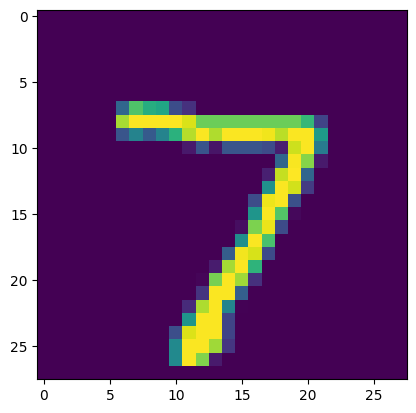

In [ ]:
show_image(x, idx=0)

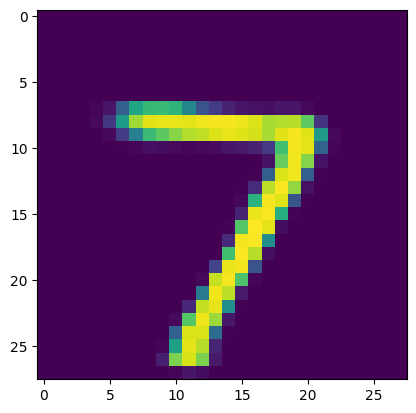

In [ ]:
show_image(x_hat, idx=0)